In [1]:
import sys
import pickle
from pathlib import Path

import pandas as pd
import geopandas as gpd 
import numpy as np
import matplotlib as mp
import matplotlib.pyplot as plt

import config, data, models, train, evaluate

In [2]:
save_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/multigraph_manual")
metadata_dir = save_dir / "metadata"

subbasins = pd.read_parquet(metadata_dir / 'subbasins.parquet', columns=['site_id', 'uparea_km2', 'is_gauge', 'outlet_id'])
subbasins.index = subbasins.index.astype(str)

In [10]:
exp_root = Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_spq")
target = 'unit_discharge'

exp_dirs = [p.parent for p in (exp_root).rglob('results/test_results.parquet')] # dirs with test_data.pkl
exp_dirs

[PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_spq/era5_no_static_20251211_233709/results'),
 PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_spq/era5_20251211_234214/results'),
 PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_spq/swot_supervised_20251211_234319/results'),
 PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_spq/swot_no_static_20251211_234320/results')]

In [11]:
exp_root =  Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_spq")
target = 'discharge'

exp_dirs = [
    "/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_spq/era5_no_static_20251211_233709",
    "/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_spq/swot_no_static_20251211_234320",
]
exp_dirs = [Path(d) / 'results' for d in exp_dirs]
exp_dirs

[PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_spq/era5_no_static_20251211_233709/results'),
 PosixPath('/nas/cee-water/cjgleason/ted/swot-ml/runs/sf_grnn_spq/swot_no_static_20251211_234320/results')]

In [8]:
def calc_discharge(df, subs):
    uparea = subs['uparea_km2'] 
    mapped_uparea = df.index.get_level_values('subbasin').map(uparea)
    
    df[('pred', 'discharge')] = df[('pred','unit_discharge')] * mapped_uparea
    df[('obs', 'discharge')] = df[('obs','unit_discharge')] * mapped_uparea
    return df

'swot no static'

In [12]:
fig_dir = exp_root / "_figures"
fig_dir.mkdir(exist_ok=True, parents=True)

from tqdm import tqdm
import evaluate

exps = []
for exp_dir in tqdm(exp_dirs):
    try:
        exp_name = ' '.join(exp_dir.parent.stem.split('_')[:-2])
        
        results = pd.read_parquet(exp_dir / 'test_results.parquet').dropna()

        if 'unit_discharge' in results['pred'].columns:
            results = calc_discharge(results, subbasins)

        bulk_m = evaluate.get_all_metrics(results)
        basin_m = evaluate.get_basin_metrics(results)

        # with open(exp_dir / "test_metrics.pkl", 'rb') as f:
        #     bulk_m, basin_m = pickle.load(f)
        
        exps.append((exp_name, results, bulk_m, basin_m))
    except Exception as e:
        print(f"{exp_name}: {e}")
        pass

exps = sorted(exps, key=lambda x: x[0])

100%|██████████| 2/2 [00:25<00:00, 12.54s/it]


In [67]:
exps[0] = ('ERA5',) + exps[0][1:]
exps[1] = ('ERA5 + SWOT',) + exps[1][1:]

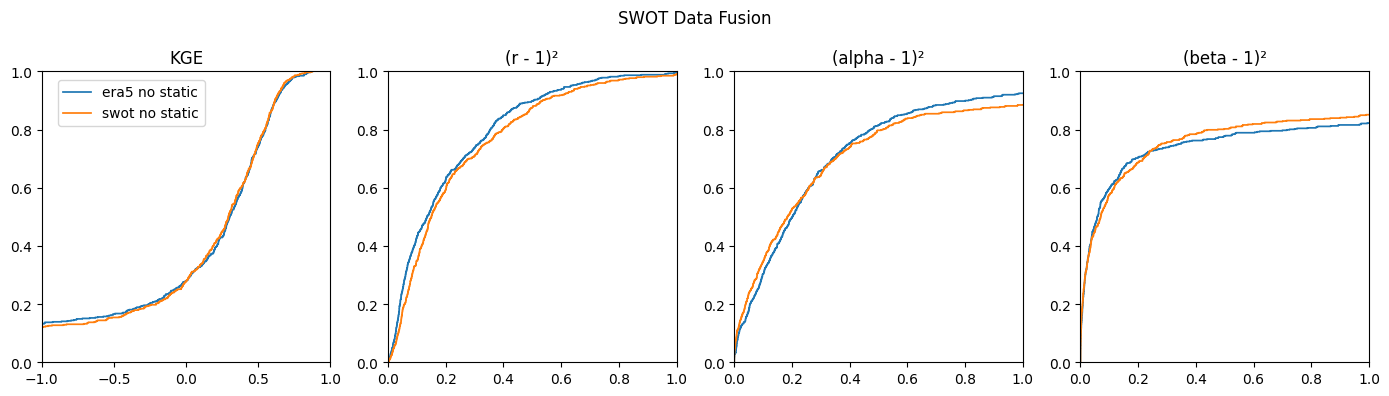

In [13]:
plt.close('all')

target = 'discharge'
num_models = len(exps)

metric_names = {
    'KGE': 'KGE',
    'corr': '(r - 1)²',
    'alpha': '(alpha - 1)²',
    'beta': '(beta - 1)²'
}

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes = axes.flatten()

for ax, (name, title) in zip(axes, metric_names.items()):
    for exp_name, results, bulk_metrics, basin_metrics in exps:
        x = np.array(basin_metrics[target][name], dtype=float)
        
        if name in ['alpha', 'beta', 'corr']:
            x = (x-1)**2
        
        
        x = x[~np.isnan(x)]
        ax.ecdf(x, linewidth=1.25, label=exp_name)
    
    ax.set_title(f"{title}")

axes[0].set_xlim([-1, 1])
axes[1].set_xlim([0, 1])
axes[2].set_xlim([0, 1])
axes[3].set_xlim([0, 1])

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.04, 0.82))

# fig.subplots_adjust(left=0.1, right=0.95, bottom=0.2, top=0.95, wspace=0.3, hspace=0.4)
plt.suptitle('SWOT Data Fusion')
plt.tight_layout()
plt.show()

# fig.savefig(fig_dir / f"KGE_decomp.png", dpi=300)

Index(['ECCC-11AA025', 'USGS-06185500', 'USGS-06172310', 'USGS-06155500',
       'USGS-06154100', 'USGS-06140500', 'USGS-06135000', 'USGS-06329500',
       'USGS-06115200', 'USGS-06151500',
       ...
       'USGS-03292494', 'USGS-06918250', 'USGS-07261090', 'USGS-07260800',
       'USGS-07263115', 'USGS-06354050', 'USGS-06680500', 'USGS-03324095',
       'USGS-07026500', 'USGS-06767970'],
      dtype='object', name='subbasin', length=597)

In [19]:
import xarray as xr

basin_mask = (subbasins['outlet_id'] == 'USGS-07374000')
test_sub_mask = subbasins.index.isin(results.index.get_level_values('subbasin').unique())
basin_gauges = subbasins[basin_mask & test_sub_mask].index
basin_ds = xr.open_zarr("/scratch4/workspace/tlanghorst_umass_edu-swot-ml-zarr/zbs_batched/USGS-07374000")
gauge_ds = basin_ds.sel(subbasin=basin_gauges)


# ds = ds.sel(subbasin=reach_id, date=slice(start_date, end_date))
# has_swot_obs = ~np.isnan(ds['d_wse_river'].to_numpy())

In [20]:
gauge_swot_count = (~gauge_ds['d_wse_river'].to_dataframe().isna()).groupby('subbasin').apply(sum)

gauge_swot_count.sort_values(by='d_wse_river')

/tmp/ipykernel_3831680/809201948.py:1: FutureWarning: The provided callable <built-in function sum> is currently using np.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string np.sum instead.
  gauge_swot_count = (~gauge_ds['d_wse_river'].to_dataframe().isna()).groupby('subbasin').apply(sum)
/nas/cee-water/cjgleason/ted/swot-ml/.venv/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


,d_wse_river
subbasin,
ECCC-11AA025,0
USGS-06354050,0
USGS-06354000,0
USGS-06351200,0
USGS-06349000,0
...,...
USGS-06185500,66
USGS-06770200,69
USGS-06438500,76


In [35]:
gauge_swot_count

,d_wse_river
subbasin,
USGS-06329500,92
USGS-06799000,77
USGS-06438500,76
USGS-06770200,69
USGS-06185500,66
...,...
USGS-03597590,0
USGS-03588500,0
USGS-03572690,0


In [46]:
gauge_swot_count.rename(columns={'d_wse_river':'num_swot_obs'})

,num_swot_obs
subbasin,
USGS-06329500,92
USGS-06799000,77
USGS-06438500,76
USGS-06770200,69
USGS-06185500,66
...,...
USGS-03597590,0
USGS-03588500,0
USGS-03572690,0


(-1.0, 1.0)

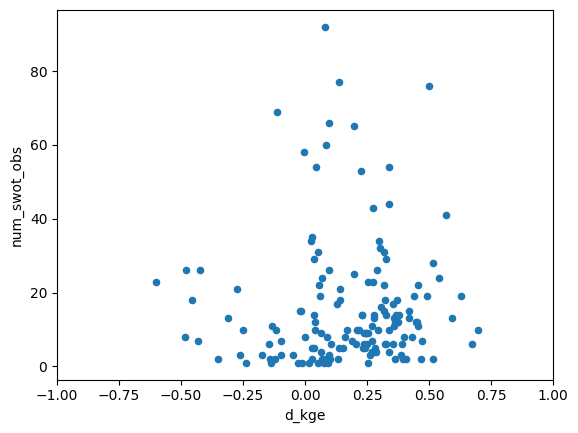

In [49]:
joined_kge = exps[0][3][target]['KGE'].rename('era5').to_frame().join(exps[1][3][target]['KGE'].rename('swot'))
joined_kge['d_kge'] = joined_kge['swot'] - joined_kge['era5'] 
joined_kge = joined_kge.join(gauge_swot_count.rename(columns={'d_wse_river':'num_swot_obs'}))
joined_kge = joined_kge[joined_kge['num_swot_obs']>0]

joined_kge.plot.scatter('d_kge','num_swot_obs')
plt.xlim([-1, 1])

In [24]:
kge = exps[1][3][target]['KGE'].dropna().sort_values(ascending=False)

kge[kge>0]

USGS-06078500    0.883455
USGS-03262700    0.840521
USGS-05435500    0.788698
USGS-03357000    0.783786
USGS-05482500     0.78317
                   ...   
USGS-06482020    0.005582
USGS-06795500    0.004928
USGS-03302220     0.00167
USGS-06018500    0.001391
USGS-06351200    0.000288
Name: KGE, Length: 431, dtype: object

In [13]:
basin_id

'USGS-07374000'

In [73]:
has_swot_obs.sum()

11

0
era5: 0.82
swot supervised: 0.88


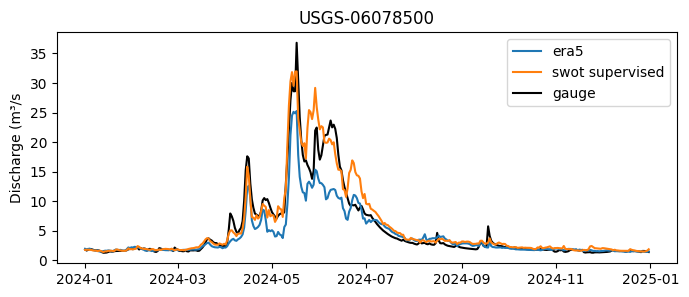

In [23]:
import xarray as xr

reach_id = 'USGS-06078500'
start_date = "2024-01-01"
end_date = "2024-12-31"
metric = 'KGE'

# Horrible hackishness
basin_id = subbasins.loc[reach_id]['outlet_id']
ds = xr.open_zarr(f"/scratch4/workspace/tlanghorst_umass_edu-swot-ml-zarr/zbs_batched/{basin_id}")
ds = ds.sel(subbasin=reach_id, date=slice(start_date, end_date))
has_swot_obs = ~np.isnan(ds['d_wse_river'].to_numpy())

print(np.sum(has_swot_obs))

fig, ax = plt.subplots(1, 1, figsize=(8, 3))

for exp_name, results, bulk_metrics, basin_metrics in exps: 
    xs = results.xs(reach_id, level='subbasin').sort_index()
    xs = xs.droplevel(0,0)
    xs = xs.loc[start_date:end_date]

    x = xs.index
    y = xs['pred'][target]
    plt.plot(x, y, label=exp_name)
    
    print(f"{exp_name}: {basin_metrics.loc[reach_id][target][metric]:0.2f}")
    
ax.plot(xs.index, xs['obs'][target], color='black', zorder=0, label='gauge')

plt.legend()
plt.title(reach_id)
plt.ylabel("Discharge (m³/s")
plt.show()
fig.savefig(fig_dir / f"timeseries_{reach_id}.png", dpi=300)

In [25]:
gauge_swot_count = gauge_swot_count.sort_values(by='d_wse_river', ascending=False)

In [106]:

reach_ds = ds.sel(subbasin=reach_id, date=slice(start_date, end_date))
date = reach_ds.date.values
d_wse = reach_ds['d_wse_river'].values
# plt.scatter(date,d_wse)

USGS-06329500: 92
era5: -0.04
swot supervised: 0.04


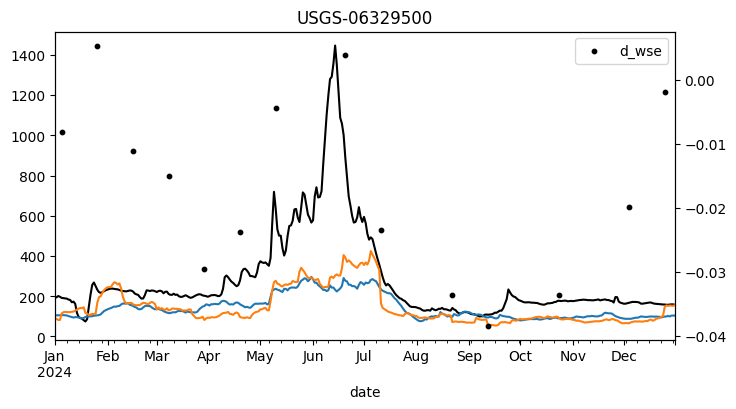

USGS-06799000: 77
era5: 0.35
swot supervised: 0.48


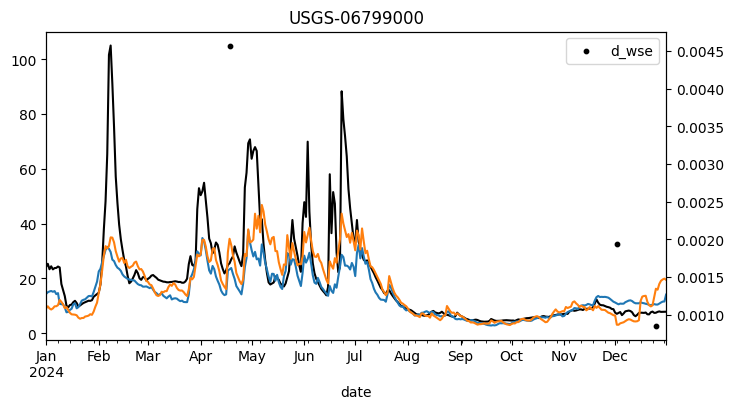

USGS-06438500: 76
era5: 0.08
swot supervised: 0.58


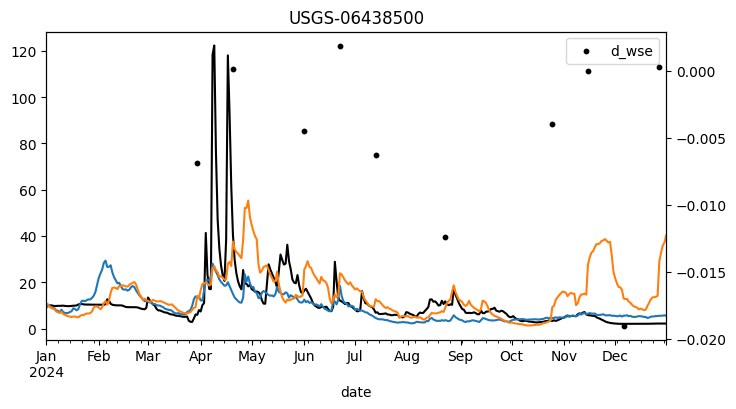

USGS-06770200: 69
era5: 0.28
swot supervised: 0.16


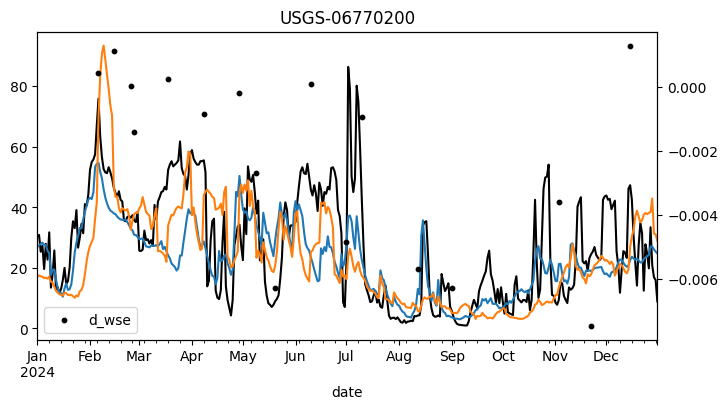

USGS-06185500: 66
era5: -0.02
swot supervised: 0.08


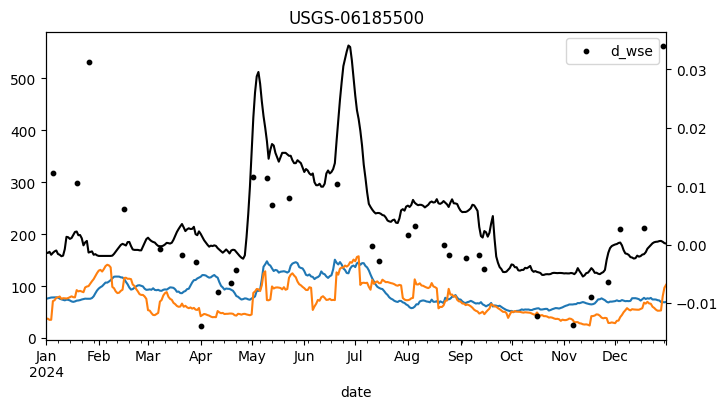

USGS-06287800: 65
era5: 0.02
swot supervised: 0.22


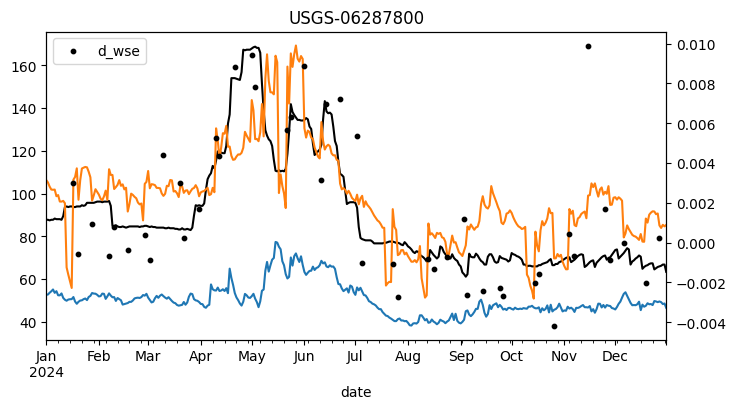

USGS-06777495: 60
era5: 0.19
swot supervised: 0.28


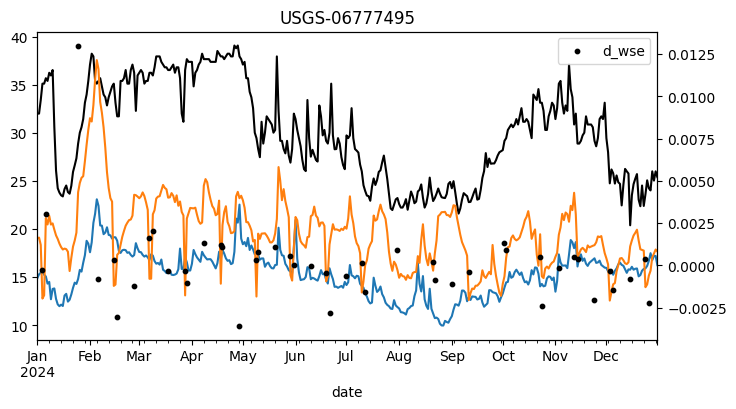

USGS-06336000: 58
era5: 0.44
swot supervised: 0.43


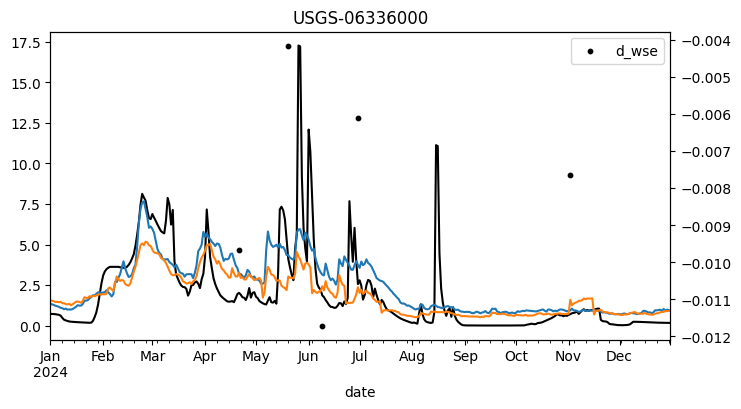

USGS-06446500: 54
era5: -0.02
swot supervised: 0.03


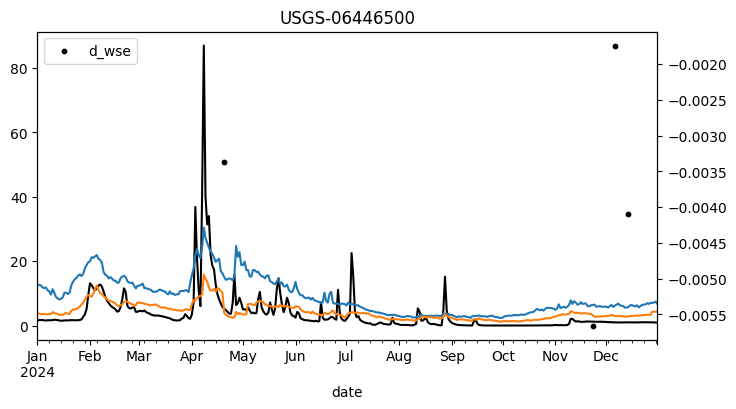

USGS-03294500: 54
era5: -0.36
swot supervised: -0.03


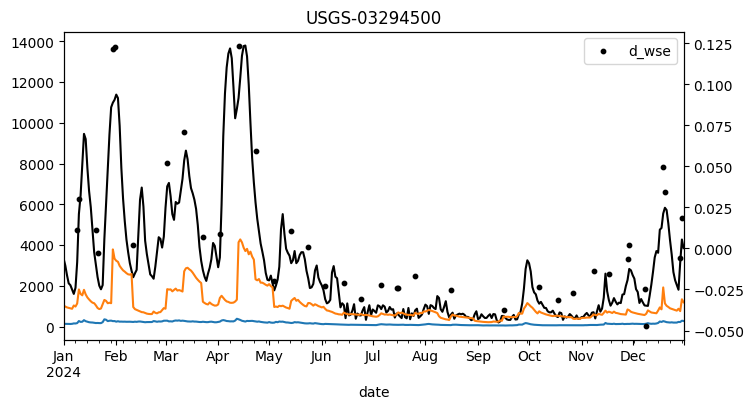

USGS-05355250: 53
era5: -0.16
swot supervised: 0.07


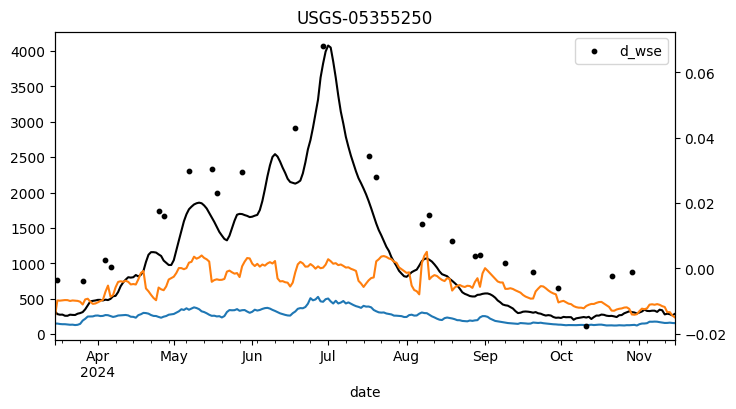

USGS-06040000: 44
era5: 0.26
swot supervised: 0.60


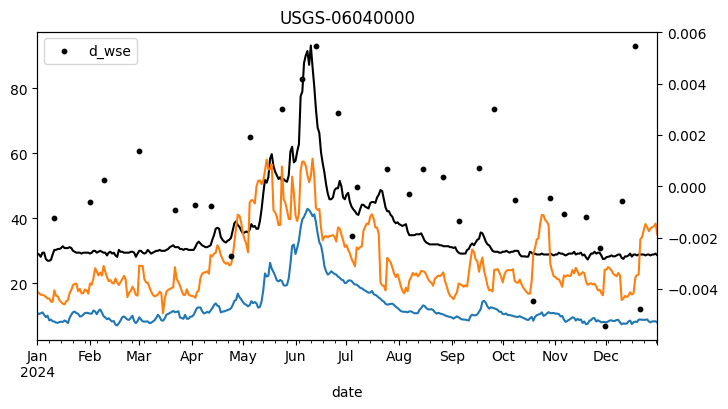

USGS-03292494: 43
era5: -0.32
swot supervised: -0.04


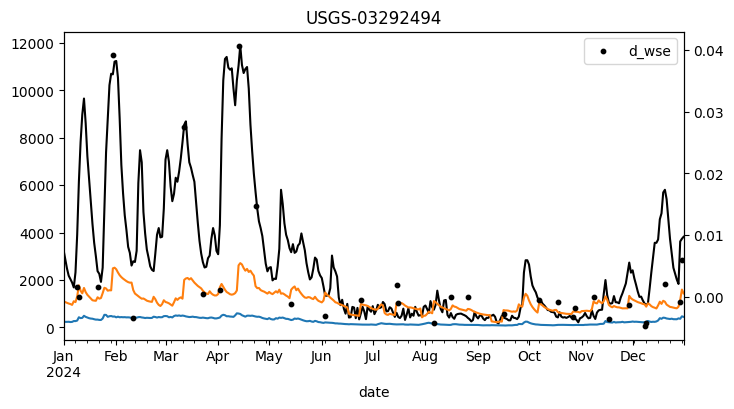

USGS-06801000: 41
era5: -0.08
swot supervised: 0.49


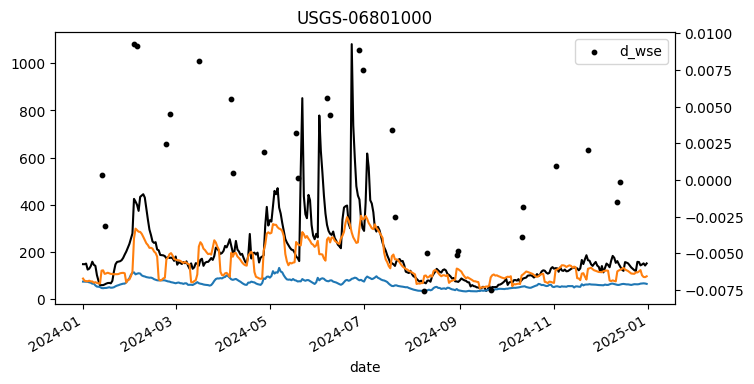

USGS-05344490: 35
era5: 0.29
swot supervised: 0.32


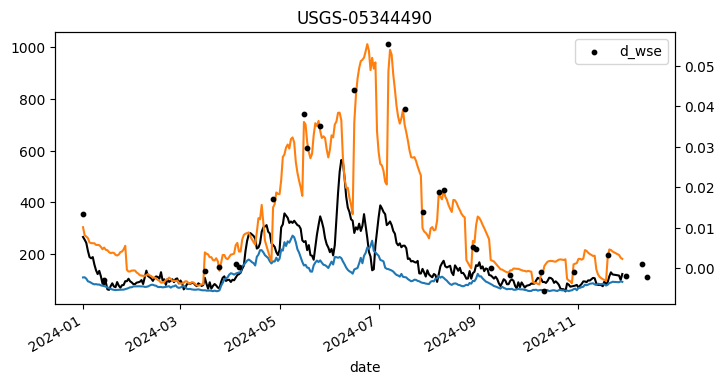

USGS-06324500: 34
era5: 0.22
swot supervised: 0.24


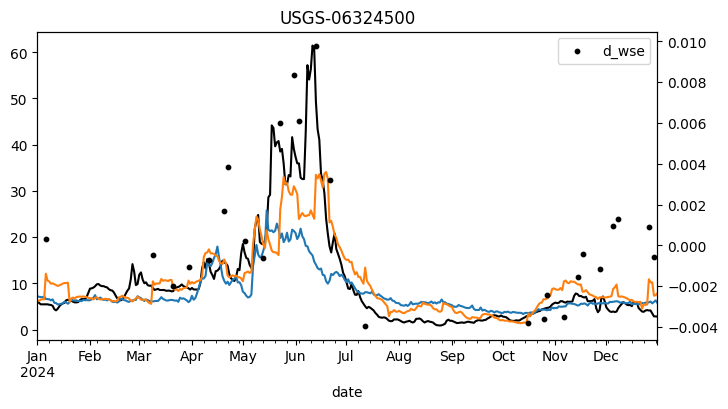

USGS-05369500: 34
era5: -0.01
swot supervised: 0.28


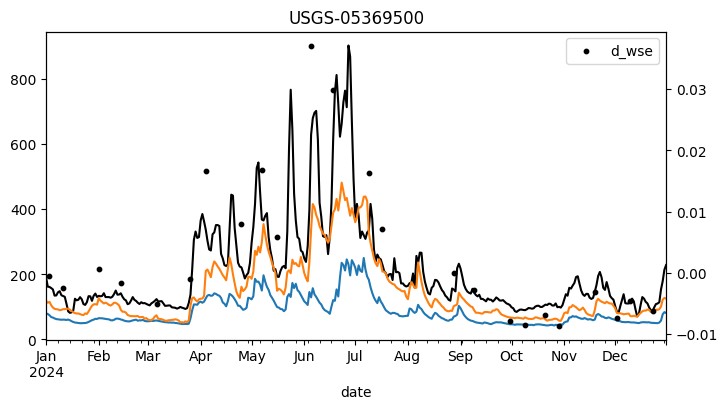

USGS-05344500: 32
era5: -0.23
swot supervised: 0.07


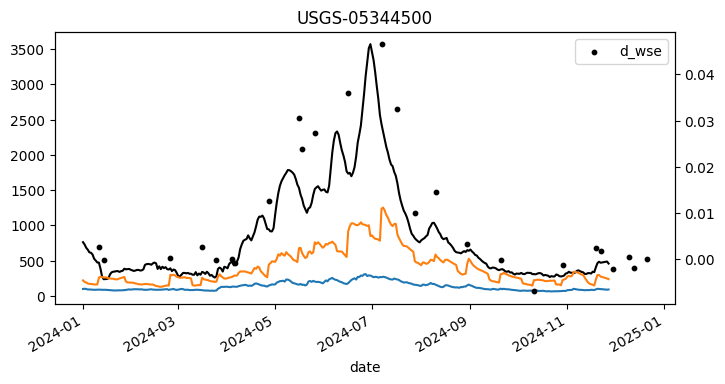

USGS-07032000: 31
era5: -0.48
swot supervised: -0.42


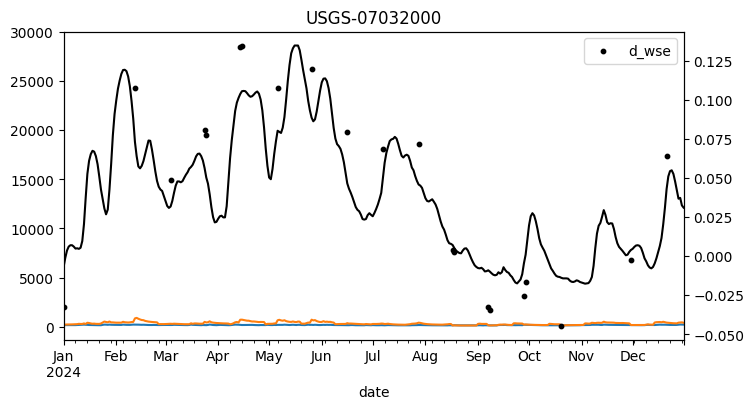

USGS-07060500: 31
era5: -0.17
swot supervised: 0.14


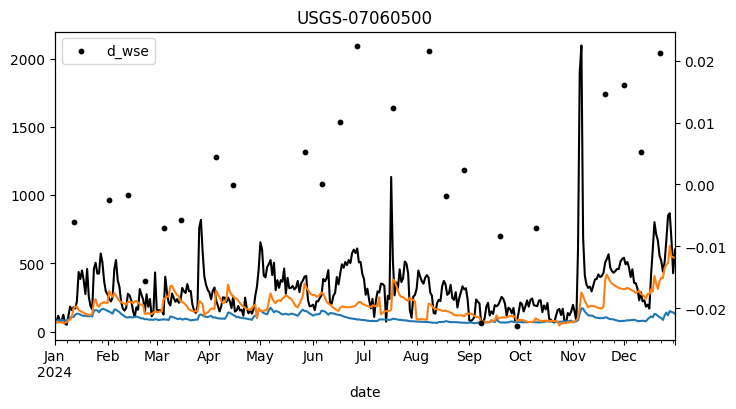

In [28]:
metric = 'KGE'
target='discharge'
start_date = '2024-01-01'
end_date = '2024-12-31'
colors = ['tab:blue','tab:orange']

ds = xr.open_zarr(f"/scratch4/workspace/tlanghorst_umass_edu-swot-ml-zarr/zbs_batched/{basin_id}")

for reach_id in gauge_swot_count.iloc[:20].index:
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))

    print(f"{reach_id}: {gauge_swot_count.loc[reach_id].item()}")

    for (exp_name, results, bulk_metrics, basin_metrics), color in zip(exps, colors): 
        x = results.xs(reach_id, level='subbasin').sort_index()
        x = x.droplevel(0,0)
        x = x.loc[start_date:end_date]
        x['pred'][target].plot(ax=ax, color = color, label=exp_name)
        print(f"{exp_name}: {basin_metrics.loc[reach_id][target][metric]:0.2f}")

    x['obs'][target].plot(color='black', ax=ax, zorder=0, label='gauge')

    ax2 = ax.twinx()  # shares x axis but has its own y axis
    reach_ds = ds.sel(subbasin=reach_id, date=slice(start_date, end_date))
    date = reach_ds.date.values
    d_wse = reach_ds['d_wse_river'].values / 50
    ax2.scatter(date, d_wse, color='black', s=10, zorder=10, label='d_wse')
        
    
    plt.legend()
    plt.title(reach_id)
    plt.show()

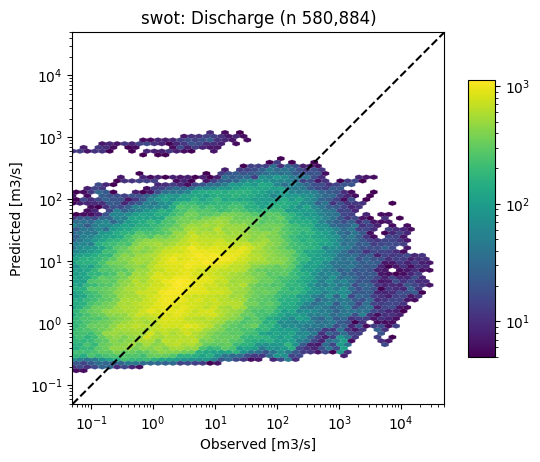

In [131]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

exp_idx = 1
name = exps[exp_idx][0]

x = exps[exp_idx][1]['obs'][target]
y = exps[exp_idx][1]['pred'][target]
positive_mask = (x > 0) & (y > 0)
x = x[positive_mask]
y = y[positive_mask]

min_val = 5E-2
max_val = 5E4
log_min = np.log10(min_val)
log_max = np.log10(max_val)

hb = ax.hexbin(x, y, gridsize=(50,50), bins='log', mincnt=5,
            linewidth=0.1,
            extent=(log_min, log_max, log_min, log_max),
            xscale='log', yscale='log')
plt.colorbar(hb, shrink=0.6, aspect=10, anchor=(0,0.5))

# Add a 1:1 line over the min and max of x and y
ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5)

# Setting axes to be square and equal range
ax.axis('square')
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.set_title(f"{name}: Discharge (n {len(x):,})")
ax.set_xlabel(f'Observed [m3/s]')
ax.set_ylabel(f'Predicted [m3/s]')
plt.show()

# fig.savefig(fig_dir / f"{name}_bulk_scatterplots.png", dpi=300)